# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Noah Demmenie
* Username: ndemmenie
* Student number: S6294588
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

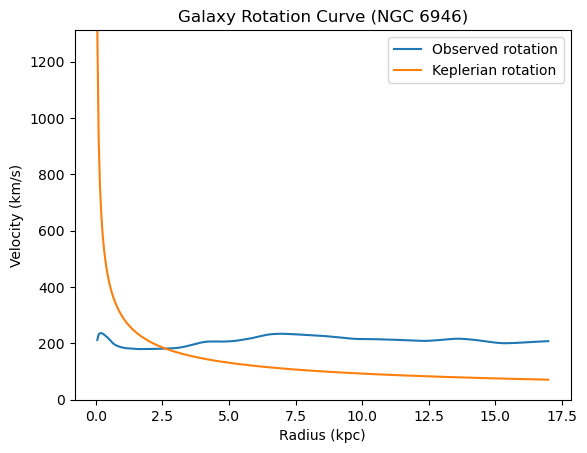

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import M_sun, G
from astropy import units as u

data = np.loadtxt("rotcur.dat.txt")

# Extract observed data and remove all zero and negative radius values (otherwise we would get imaginary numbers or division by zero)

R = data[:,0]
V = data[:,1]
mask = R > 0
R = R[mask]
V = V[mask]

# Compute Keplerian velocity in the right units

M_kg = 2e10 * M_sun
R_kpc = R * u.kpc
V_kepler_m_s = np.sqrt(G * M_kg / R_kpc)
V_kepler_km_s = V_kepler_m_s.to_value(u.km / u.s)

# Create and load Keplerian curve data

combined_data = np.column_stack((R, V_kepler_km_s))

np.savetxt("keplerian_curve.txt", combined_data)
kepler_data = np.loadtxt("keplerian_curve.txt")

# Extract Keplerian curve data

R_kepler = kepler_data[:,0]
V_kepler = kepler_data[:,1]

# Plot everything

plt.plot(R, V, label="Observed rotation")
plt.plot(R_kepler, V_kepler, label="Keplerian rotation")
plt.xlabel("Radius (kpc)")
plt.ylabel("Velocity (km/s)")
plt.ylim(0, max(V_kepler))
plt.title("Galaxy Rotation Curve (NGC 6946)")
plt.legend()
plt.show()

**The observed rotation curve is approximately constant as the radius increases, whereas the Keplerian curve decreases as $\frac{1}{\sqrt{r}}$. This indicates that the mass of the galaxy is not concentrated at the center but distributed in an extended halo, suggesting the presence of dark matter.**

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

mean slice = -0.04422167503569734
std slice = 1.0027197319680197


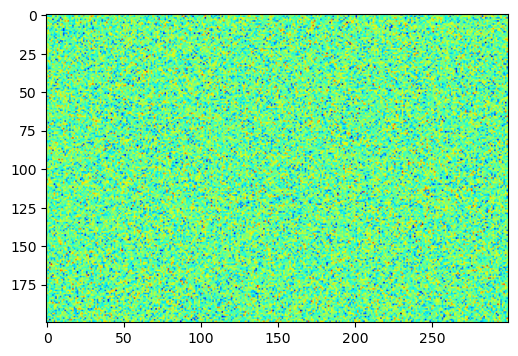

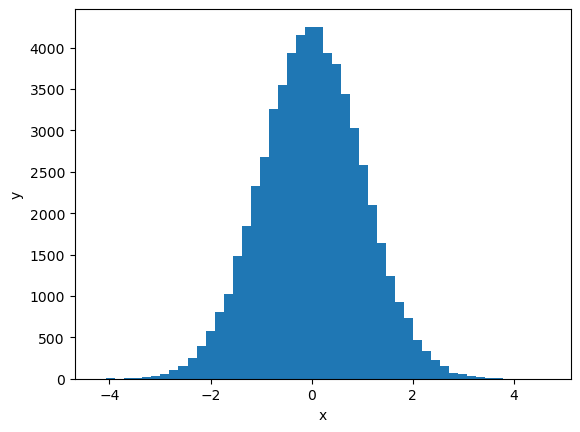

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Create and plot image with the right dimensions

image = np.random.normal(0, 1.0, (200, 300))
plt.figure(figsize=(8,4))
plt.imshow(image, cmap = "jet")

# Take a slice of the image and compute its mean and std

slice_image = image[0:30, 0:30]
slice_mean = np.mean(slice_image)
slice_std = np.std(slice_image)
print(f"mean slice = {slice_mean}")
print(f"std slice = {slice_std}")

# Ravel data and plot histogram

plt.figure()
values = image.ravel()
plt.hist(values, bins=50)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

**The mean and std are what I expected because its practically respectively 0 and 1.0. The distribution is the Gaussian distribution.**

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area of ellpise with semi-major equal to 3 and semi-minor equal to 2 = 18.84955592153876
Perimeter of ellpise with semi-major equal to 3 and semi-minor equal to 2 = 15.865439589251233
Center: (0, 0), Semi major axis: 3, Semi minor axis: 2, Angle: 0


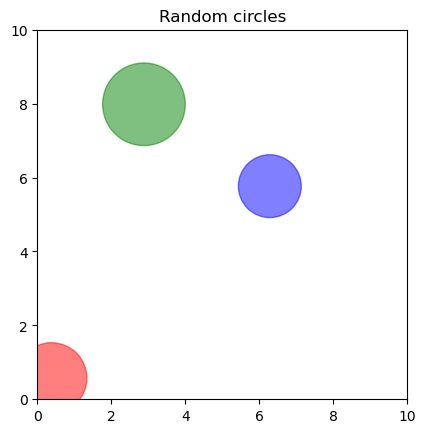

In [6]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np

# Define class with methods

class AstroEllipse(Ellipse):

    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **kwargs):

        assert semi_major >= semi_minor

        XY = (xc, yc)
        angle_mpl = position_angle
        height = 2 * semi_major
        width = 2 * semi_minor

        super().__init__(XY, width, height, angle=angle_mpl, **kwargs)

        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.XY = XY
        self.angle_mpl = angle_mpl

    def area(self):
        return np.pi * self.semi_major * self.semi_minor

    def perimeter(self):
        a = self.semi_major
        b = self.semi_minor
        return np.pi*((a+b)+(3*(a-b)**2)/(10*(a+b)+np.sqrt(a**2+14*a*b+b**2)))

    def __str__(self):
        return f"Center: {self.XY}, Semi major axis: {self.semi_major}, Semi minor axis: {self.semi_minor}, Angle: {self.angle_mpl}"
        
# Example

el1 = AstroEllipse(0, 0, 3, 2, 0)
print(f"Area of ellpise with semi-major equal to 3 and semi-minor equal to 2 = {el1.area()}")
print(f"Perimeter of ellpise with semi-major equal to 3 and semi-minor equal to 2 = {el1.perimeter()}")
print(el1)

# Define inherited class

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **kwargs):
        super().__init__(xc, yc, radius, radius, 0, **kwargs)

# Plot 3 random circles

fig, ax = plt.subplots()

colors = ["r", "g", "b"]

for i in colors:
    xc = np.random.uniform(0,10)
    yc = np.random.uniform(0,10)
    r = np.random.uniform(0.5,2)

    ax.add_patch(MyCircle(xc, yc, r, color=i, alpha=0.5))

ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.set_aspect('equal')
ax.set_title("Random circles")
plt.show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

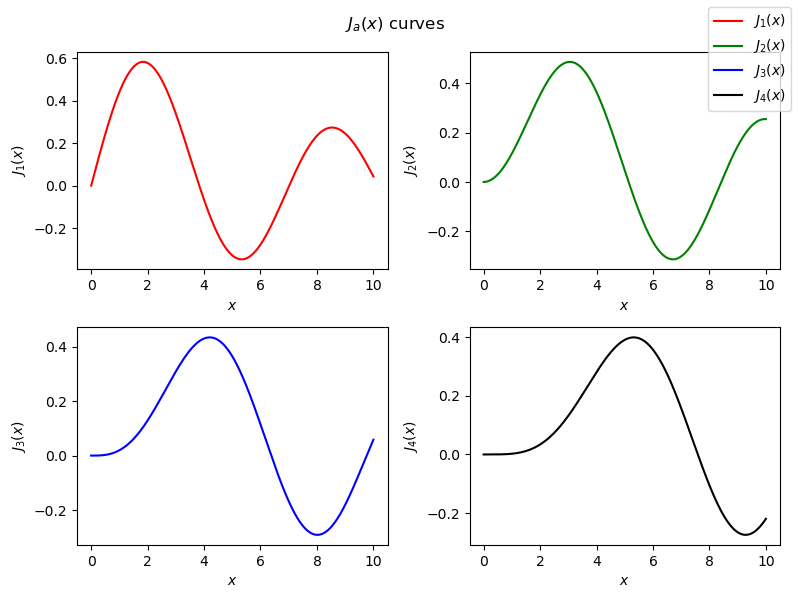

In [8]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 1000)

fig, ax = plt.subplots(2, 2, figsize = (8, 6))
axes = ax.flatten()

colors = ["r", "g", "b", "k"]
for axis, i, j in zip(axes, range(1, 5), colors):
    y = jv(i, x)
    axis.plot(x, y, label=rf"$J_{i}(x)$", color = j)
    axis.set_xlabel(r"$x$")
    axis.set_ylabel(rf"$J_{i}(x)$")
fig.legend()

fig.suptitle(r"$J_a(x)$ curves")
fig.tight_layout()
fig.savefig("bessel.png", transparent = True)
plt.show()

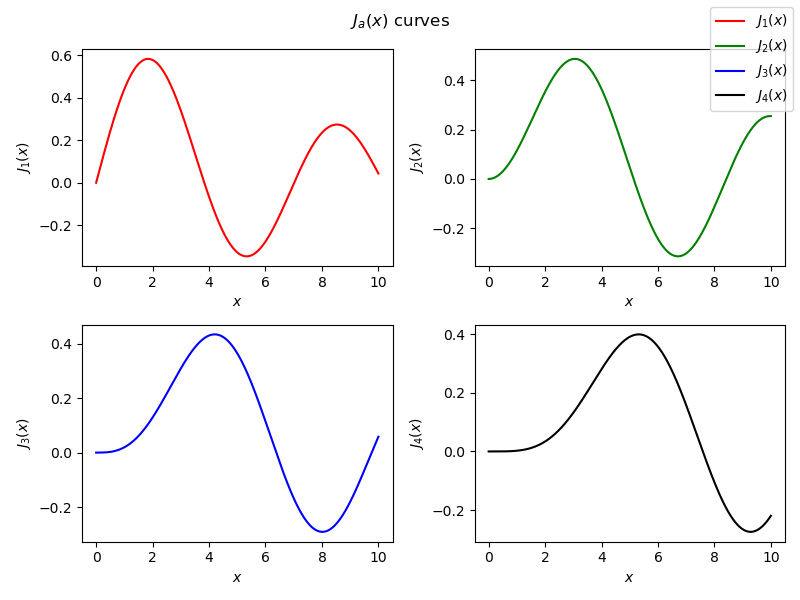

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

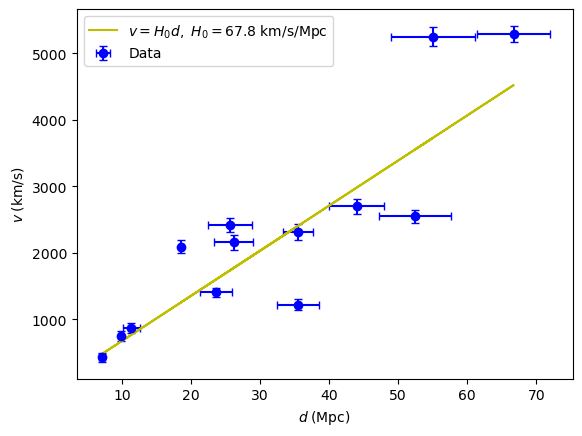

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Define data

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

# Reshape and extract data

data = np.array(data).reshape(-1, 4)
d = data[:,0]
v = data[:,1]
d_error = data[:,2]
v_error = data[:,3]
H0 = 67.8

# Plot everything

fig, ax = plt.subplots()
ax.errorbar(d, v, xerr = d_error, yerr = v_error, fmt = "o", capsize = 3, color = "b", label = "Data")
ax.plot(d, H0*d, label = rf"$v = H_0 d,\ H_0 = {H0}\ \mathrm{{km/s/Mpc}}$", color = "y") 
ax.set_xlabel(r"$d\;\mathrm{(Mpc)}$")
ax.set_ylabel(r"$v\;\mathrm{(km/s)}$")
ax.legend(loc = "upper left")
plt.show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
